# Stage 1 — Extraction (Azure Document Intelligence)

## Goal

Turn each PDF in `data/` into three parallel, metadata-tagged streams:

- **Text**
- **Tables**
- **Images**

The extraction uses Azure AI Document Intelligence's **`prebuilt-layout`** model.

Every Azure Document Intelligence response is **cached to disk**, so re-running notebook cells can load the existing response instead of calling the API again and incurring additional cost.

---

## Pipeline for This Notebook

1. **Config + Client Setup**  
   Configure Azure Document Intelligence credentials and initialize the client.

2. **`analyze_pdf_cached(pdf_path)`**  
   - Send the PDF to Azure Document Intelligence if it has not been processed before.
   - Otherwise, load the previously cached response.
   - Return the raw Document Intelligence result as a plain Python dictionary.

3. **Text Extraction**  
   - Extract paragraph-level text.
   - Preserve metadata such as:
     - Headers
     - Footers
     - Page numbers
     - Page information
   - No cleaning is performed at this stage; these roles are retained for **Stage 2**.

4. **Table Extraction**  
   - Extract table cells from the Document Intelligence response.
   - Reconstruct rows and columns.
   - Convert each table into **Markdown format**.
   - Preserve table-level and page-level metadata.

5. **Image Extraction**  
   - Read figure bounding boxes detected by Document Intelligence.
   - Use **PyMuPDF** to render the corresponding PDF page.
   - Crop the detected figure region.
   - Save each extracted figure as a **PNG** file.
   - Store metadata linking each image back to its source document and page.

6. **Process All PDFs in `data/`**  
   Run the extraction pipeline over every PDF and save the consolidated outputs as:

   - `text_units.jsonl`
   - `table_units.jsonl`
   - `image_units.jsonl`

---

## Output

This notebook produces the raw multimodal extraction output required by:

> **Stage 2 — Clean & Organize**

Stage 1 performs **extraction only**.

It does **not** perform:

- Text cleaning
- Header/footer removal
- Semantic chunking
- Embedding generation
- Vector indexing
- Image captioning
- Retrieval

In [1]:
import json
from pathlib import Path

import fitz  # PyMuPDF
import pandas as pd
from dotenv import load_dotenv
import os

from azure.ai.documentintelligence import DocumentIntelligenceClient
from azure.ai.documentintelligence.models import AnalyzeDocumentRequest
from azure.core.credentials import AzureKeyCredential

In [2]:
load_dotenv()

AZURE_DI_ENDPOINT = os.environ["AZURE_DOCUMENT_INTELLIGENCE_ENDPOINT"]
AZURE_DI_KEY = os.environ["AZURE_DOCUMENT_INTELLIGENCE_KEY"]

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DI_CACHE_DIR = DATA_DIR / "di_cache"
IMAGES_DIR = DATA_DIR / "images"
EXTRACTED_DIR = DATA_DIR / "extracted"

for d in (DI_CACHE_DIR, IMAGES_DIR, EXTRACTED_DIR):
    d.mkdir(parents=True, exist_ok=True)

RENDER_DPI = 150  # resolution used when cropping figures out of a page

PDF_PATHS = sorted(DATA_DIR.glob("*.pdf"))
PDF_PATHS

[PosixPath('/Users/rutikakadam/Documents/My Studies/Projects/multi-modal-rag/data/IPCC_AR6_WGI_Chapter07.pdf'),
 PosixPath('/Users/rutikakadam/Documents/My Studies/Projects/multi-modal-rag/data/IPCC_AR6_WGI_Chapter08.pdf')]

In [3]:
def get_di_client() -> DocumentIntelligenceClient:
    return DocumentIntelligenceClient(
        endpoint=AZURE_DI_ENDPOINT,
        credential=AzureKeyCredential(AZURE_DI_KEY),
    )

## Cached DI call

`analyze_pdf_cached` calls the `prebuilt-layout` model and writes the raw result (as a plain dict) to `data/di_cache/<pdf>.json`. Every later cell reads from this cache-or-call function, so re-running the notebook after the first successful pass costs nothing.

**Note:** figure detection in the Layout model requires a reasonably recent API version of the SDK/service. After running this on a real PDF, check that `result_dict["figures"]` isn't empty — if it is, the installed `azure-ai-documentintelligence` version may default to an older `api-version`; pin a newer one via the client's `api_version` argument if needed.

In [4]:
def analyze_pdf_cached(pdf_path: Path, client: DocumentIntelligenceClient | None = None) -> dict:
    """Return DI's prebuilt-layout result for pdf_path as a plain dict, using a disk cache."""
    cache_path = DI_CACHE_DIR / f"{pdf_path.stem}.json"
    if cache_path.exists():
        with open(cache_path, "r", encoding="utf-8") as f:
            return json.load(f)

    client = client or get_di_client()
    with open(pdf_path, "rb") as f:
        poller = client.begin_analyze_document(
            "prebuilt-layout",
            AnalyzeDocumentRequest(bytes_source=f.read()),
        )
    result_dict = poller.result().as_dict()

    with open(cache_path, "w", encoding="utf-8") as f:
        json.dump(result_dict, f)

    return result_dict

### Sanity check on one PDF before running all three

DI is billed per page — validate the client and cache work on a single document first. This also warms the cache for `PDF_PATHS[0]` so the full loop later doesn't re-call it.

In [6]:
_test_client = get_di_client()
_test_result = analyze_pdf_cached(PDF_PATHS[0], client=_test_client)

print("pages:", len(_test_result.get("pages", [])))
print("paragraphs:", len(_test_result.get("paragraphs", [])))
print("tables:", len(_test_result.get("tables", [])))
print("figures:", len(_test_result.get("figures", [])))

pages: 132
paragraphs: 5291
tables: 21
figures: 38


## Text extraction

Each DI paragraph becomes one text unit, tagged with its `role` (`pageHeader`, `pageFooter`, `pageNumber`, `sectionHeading`, `title`, or plain content). Boilerplate roles are flagged via `is_boilerplate` but **not dropped here** — filtering happens in the Stage 2 cleaning notebook, so this notebook stays a faithful, lossless extraction.

In [7]:
BOILERPLATE_ROLES = {"pageHeader", "pageFooter", "pageNumber"}


def extract_text_units(result_dict: dict, doc_id: str) -> list[dict]:
    units = []
    for idx, para in enumerate(result_dict.get("paragraphs", [])):
        content = (para.get("content") or "").strip()
        if not content:
            continue
        role = para.get("role")
        region = (para.get("boundingRegions") or [{}])[0]
        units.append({
            "doc_id": doc_id,
            "page_number": region.get("pageNumber"),
            "chunk_type": "text",
            "role": role,
            "is_boilerplate": role in BOILERPLATE_ROLES,
            "content": content,
            "bbox": region.get("polygon"),
            "raw_ref": idx,
        })
    return units

## Table extraction

Each DI table's cells (`rowIndex`, `columnIndex`, `content`, `kind`) are laid out into a grid and serialized to Markdown, so table structure survives into the embedding stage as plain text.

Known limitation: DI does not merge tables that span a page break — a split table will show up here as two separate table units. Not solved in this pass; revisit only if it actually shows up in these three PDFs.

In [8]:
def table_to_markdown(table: dict) -> str:
    n_rows, n_cols = table["rowCount"], table["columnCount"]
    grid = [["" for _ in range(n_cols)] for _ in range(n_rows)]

    header_rows = set()
    for cell in table.get("cells", []):
        r, c = cell["rowIndex"], cell["columnIndex"]
        grid[r][c] = (cell.get("content") or "").replace("\n", " ").strip()
        if cell.get("kind") == "columnHeader":
            header_rows.add(r)

    header_idx = min(header_rows) if header_rows else 0

    lines = ["| " + " | ".join(grid[header_idx]) + " |"]
    lines.append("| " + " | ".join(["---"] * n_cols) + " |")
    for r in range(n_rows):
        if r == header_idx:
            continue
        lines.append("| " + " | ".join(grid[r]) + " |")
    return "\n".join(lines)


def extract_table_units(result_dict: dict, doc_id: str) -> list[dict]:
    units = []
    for idx, table in enumerate(result_dict.get("tables", [])):
        region = (table.get("boundingRegions") or [{}])[0]
        units.append({
            "doc_id": doc_id,
            "page_number": region.get("pageNumber"),
            "chunk_type": "table",
            "content": table_to_markdown(table),
            "bbox": region.get("polygon"),
            "raw_ref": idx,
        })
    return units

## Image extraction

DI's `figures` only carry a bounding polygon per page, not pixels. So: convert the polygon (inches, DI's unit for PDFs) to PDF points (× 72), then render *just that clipped region* directly from the page at `RENDER_DPI` via PyMuPDF — this avoids rendering and cropping a full-page pixmap for every figure.

`content` is left `None` here on purpose — captioning the cropped image with a vision LLM happens in Stage 3 (chunking/embeddings), not here.

In [9]:
def crop_figure_image(pdf_path: Path, page_number: int, polygon: list[float], dpi: int = RENDER_DPI, padding_pt: float = 2.0):
    """polygon is DI's [x1, y1, x2, y2, ...] in inches (1-indexed page_number)."""
    xs, ys = polygon[0::2], polygon[1::2]
    rect = fitz.Rect(
        min(xs) * 72 - padding_pt,
        min(ys) * 72 - padding_pt,
        max(xs) * 72 + padding_pt,
        max(ys) * 72 + padding_pt,
    )
    doc = fitz.open(pdf_path)
    page = doc[page_number - 1]
    zoom = dpi / 72
    pix = page.get_pixmap(matrix=fitz.Matrix(zoom, zoom), clip=rect)
    doc.close()
    return pix


def extract_image_units(result_dict: dict, doc_id: str, pdf_path: Path) -> list[dict]:
    units = []
    out_dir = IMAGES_DIR / doc_id
    out_dir.mkdir(parents=True, exist_ok=True)

    for idx, figure in enumerate(result_dict.get("figures", [])):
        region = (figure.get("boundingRegions") or [{}])[0]
        page_number = region.get("pageNumber")
        polygon = region.get("polygon")
        if page_number is None or not polygon:
            continue

        pix = crop_figure_image(pdf_path, page_number, polygon)
        image_path = out_dir / f"p{page_number}_fig{idx}.png"
        pix.save(image_path)

        units.append({
            "doc_id": doc_id,
            "page_number": page_number,
            "chunk_type": "image",
            "content": None,  # captioned in Stage 3
            "image_path": str(image_path.relative_to(PROJECT_ROOT)),
            "bbox": polygon,
            "raw_ref": idx,
        })
    return units

## Putting it together, and running over all PDFs

`extract_pdf` combines all three extractors for one PDF. This is the exact function boundary that becomes `ingest.py`'s public API once this notebook's logic gets promoted into the package.

In [10]:
def extract_pdf(pdf_path: Path, client: DocumentIntelligenceClient | None = None) -> dict:
    doc_id = pdf_path.name
    result_dict = analyze_pdf_cached(pdf_path, client=client)

    return {
        "text_units": extract_text_units(result_dict, doc_id),
        "table_units": extract_table_units(result_dict, doc_id),
        "image_units": extract_image_units(result_dict, doc_id, pdf_path),
    }

In [11]:
client = get_di_client()

all_text_units, all_table_units, all_image_units = [], [], []

for pdf_path in PDF_PATHS:
    print(f"Extracting {pdf_path.name} ...")
    result = extract_pdf(pdf_path, client=client)
    all_text_units.extend(result["text_units"])
    all_table_units.extend(result["table_units"])
    all_image_units.extend(result["image_units"])
    print(
        f"  text={len(result['text_units'])} "
        f"table={len(result['table_units'])} "
        f"image={len(result['image_units'])}"
    )

Extracting IPCC_AR6_WGI_Chapter07.pdf ...
  text=5291 table=21 image=38
Extracting IPCC_AR6_WGI_Chapter08.pdf ...
  text=5315 table=4 image=35


## Save consolidated outputs

One JSONL file per stream under `data/extracted/`. This is the handoff point to the Stage 2 (clean & organize) notebook — it should only need to read these three files plus the PNGs already saved under `data/images/`.

In [12]:
def save_jsonl(units: list[dict], path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for unit in units:
            f.write(json.dumps(unit) + "\n")


save_jsonl(all_text_units, EXTRACTED_DIR / "text_units.jsonl")
save_jsonl(all_table_units, EXTRACTED_DIR / "table_units.jsonl")
save_jsonl(all_image_units, EXTRACTED_DIR / "image_units.jsonl")

print(f"text_units:  {len(all_text_units)}")
print(f"table_units: {len(all_table_units)}")
print(f"image_units: {len(all_image_units)}")

text_units:  10606
table_units: 25
image_units: 73


## Sanity-check preview

Spot-check a few rows of each stream, and open one saved figure image directly, before moving to Stage 2.

In [13]:
pd.DataFrame(all_text_units).sample(5)

,doc_id,page_number,chunk_type,role,is_boilerplate,content,bbox,raw_ref
2255,IPCC_AR6_WGI_Chapter07.pdf,44,text,NaN,False,-14%,"[6.6504, 8.2989, 7.0681, 8.2989, 7.0681, 8.500...",2255
6604,IPCC_AR6_WGI_Chapter08.pdf,48,text,NaN,False,"(b) Southern Hemisphere, annual, total","[4.546, 0.8766, 6.3932, 0.8712, 6.3937, 1.0299...",1313
4640,IPCC_AR6_WGI_Chapter07.pdf,116,text,NaN,False,"Köhler, P., B. De Boer, A.S. Von Der Heydt, L....","[0.6992, 6.4882, 4.125, 6.4903, 4.1247, 7.0872...",4640
1590,IPCC_AR6_WGI_Chapter07.pdf,37,text,NaN,False,-0.84 [-1.45 to -0.25],"[6.5749, 7.9173, 7.7184, 7.9182, 7.7183, 8.062...",1590
8675,IPCC_AR6_WGI_Chapter08.pdf,109,text,pageNumber,True,1163,"[7.4999, 10.5977, 7.7909, 10.5975, 7.791, 10.7...",3384


In [14]:
pd.DataFrame(all_table_units).head(3)

,doc_id,page_number,chunk_type,content,bbox,raw_ref
0,IPCC_AR6_WGI_Chapter07.pdf,2,table,| Executive Summary | | 925 | 7.5 | Estimates...,"[0.6511, 1.6033, 7.7671, 1.5856, 7.783, 8.4693...",0
1,IPCC_AR6_WGI_Chapter07.pdf,16,table,| Component | 1971-2018 | | 1993-2018 | | 20...,"[0.6985, 1.2671, 7.7202, 1.2702, 7.7199, 3.202...",1
2,IPCC_AR6_WGI_Chapter07.pdf,21,table,"| 2×CO2 Experiments (Smith et al., 2018b) | St...","[0.7794, 2.6499, 4.2225, 2.6496, 4.2227, 5.797...",2


,doc_id,page_number,chunk_type,content,image_path,bbox,raw_ref
0,IPCC_AR6_WGI_Chapter07.pdf,1,image,None,data/images/IPCC_AR6_WGI_Chapter07.pdf/p1_fig0...,"[1.7464, 2.8012, 2.2067, 2.8017, 2.2067, 3.558...",0
1,IPCC_AR6_WGI_Chapter07.pdf,7,image,None,data/images/IPCC_AR6_WGI_Chapter07.pdf/p7_fig1...,"[0.7772, 5.9239, 7.7821, 5.9264, 7.7797, 10.11...",1
2,IPCC_AR6_WGI_Chapter07.pdf,8,image,None,data/images/IPCC_AR6_WGI_Chapter07.pdf/p8_fig2...,"[0.7551, 0.8275, 7.6763, 0.8249, 7.6772, 6.477...",2


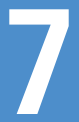

In [15]:
from IPython.display import Image as IPyImage

df_images = pd.DataFrame(all_image_units)
display(df_images.head(3))

if len(df_images):
    display(IPyImage(filename=str(PROJECT_ROOT / df_images.iloc[0]["image_path"])))

## Next: Stage 2 — Clean & organize

Outputs of this notebook (read by the next one):

- `data/di_cache/*.json` — raw DI responses (so this notebook never needs to re-run against the API)
- `data/extracted/text_units.jsonl`, `table_units.jsonl`, `image_units.jsonl`
- `data/images/<doc_id>/*.png` — cropped figures

Stage 2 will: drop/flag `is_boilerplate` text units, de-hyphenate wrapped words, and validate the shared metadata schema (`doc_id`, `page_number`, `chunk_type`) across all three streams before semantic chunking.